# 08 CNN-GRU


Train a compact convolutional-recurrent model that extracts local temporal patterns before GRU sequence modeling.


In [1]:
from pathlib import Path
import sys

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\User\Documents\deep-learning\deep-learning


## 2. Shared training and evaluation imports


In [2]:
import json
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

from src.config import BATCH_SIZE, LEARNING_RATE, MAX_EPOCHS, PATIENCE, RANDOM_SEED, SEQUENCE_CHANNELS, WEIGHT_DECAY, WINDOW_SAMPLES
from src.helpers import count_parameters, set_seed
from src.training import (
    pos_weight_from_labels,
    save_model_artifacts,
    train_with_early_stopping,
)
from src.evaluation import (
    binary_metrics,
    collect_probabilities,
    per_subject_metrics,
    prediction_table,
    select_threshold,
)

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
# Shared setup is imported above; model architecture remains defined in this notebook.


## 3. CNN-GRU model definition


In [4]:
from __future__ import annotations

import torch
from torch import nn


class CNNGRUClassifier(nn.Module):
    def __init__(self, input_channels: int = 6, conv_channels: int = 32, hidden_size: int = 64, dropout: float = 0.3) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, conv_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        self.gru = nn.GRU(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        _, hidden = self.gru(x)
        return self.classifier(hidden[-1])


## 4. Load sequence tensors


In [5]:
sequence_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
preprocessing_dir = PROJECT_ROOT / "artifacts" / "preprocessing"

X_train = torch.load(sequence_dir / "X_train.pt").float()
y_train = torch.load(sequence_dir / "y_train.pt").float()
X_validation = torch.load(sequence_dir / "X_validation.pt").float()
y_validation = torch.load(sequence_dir / "y_validation.pt").float()
X_test = torch.load(sequence_dir / "X_test.pt").float()
y_test = torch.load(sequence_dir / "y_test.pt").float()

metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")
with (preprocessing_dir / "sequence_channels.json").open("r", encoding="utf-8") as handle:
    saved_sequence_channels = json.load(handle)

assert saved_sequence_channels == SEQUENCE_CHANNELS
assert X_train.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_validation.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_test.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_validation).all()
assert torch.isfinite(X_test).all()
assert set(y_train.numpy().astype(int)).issubset({0, 1})
assert set(y_validation.numpy().astype(int)).issubset({0, 1})
assert set(y_test.numpy().astype(int)).issubset({0, 1})
assert len(metadata_train) == len(y_train)
assert len(metadata_validation) == len(y_validation)
assert len(metadata_test) == len(y_test)
assert np.array_equal(metadata_train["binary_label"].to_numpy(), y_train.numpy().astype(int))
assert np.array_equal(metadata_validation["binary_label"].to_numpy(), y_validation.numpy().astype(int))
assert np.array_equal(metadata_test["binary_label"].to_numpy(), y_test.numpy().astype(int))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_validation["subject_id"]))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))
assert set(metadata_validation["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))

X_train.shape, X_validation.shape, X_test.shape


(torch.Size([1429, 960, 6]),
 torch.Size([287, 960, 6]),
 torch.Size([426, 960, 6]))

## 5. Load window metadata


In [6]:
metadata_validation.head(), metadata_test.head()


(   window_id subject_id       split  label  binary_label  start_sample  \
 0       1429         S5  validation      1             0          8940   
 1       1430         S5  validation      1             0          9420   
 2       1431         S5  validation      1             0          9900   
 3       1432         S5  validation      1             0         10380   
 4       1433         S5  validation      1             0         10860   
 
    end_sample  start_time_seconds  end_time_seconds  
 0        9900             279.375           309.375  
 1       10380             294.375           324.375  
 2       10860             309.375           339.375  
 3       11340             324.375           354.375  
 4       11820             339.375           369.375  ,
    window_id subject_id split  label  binary_label  start_sample  end_sample  \
 0       1716         S2  test      1             0          9810       10770   
 1       1717         S2  test      1             0    

## 6. Create TensorDataset objects


In [7]:
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)


## 7. Create DataLoaders


In [8]:
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 8. Inspect input and output shapes


In [9]:
model = CNNGRUClassifier(input_channels=X_train.shape[2]).to(device)
print(X_train[:4].shape)
print(model(X_train[:4].to(device)).shape)


torch.Size([4, 960, 6])
torch.Size([4, 1])


## 9. Define loss and optimizer


In [10]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


## 10. Train without imbalance correction


In [11]:
set_seed(42)
unweighted_model = CNNGRUClassifier(input_channels=X_train.shape[2]).to(device)
unweighted_criterion = torch.nn.BCEWithLogitsLoss()
unweighted_optimizer = torch.optim.Adam(unweighted_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
unweighted_model, unweighted_history, unweighted_training_summary = train_with_early_stopping(unweighted_model, train_loader, validation_loader, unweighted_criterion, unweighted_optimizer, device, MAX_EPOCHS, PATIENCE, gradient_clip=1.0)
unweighted_history.tail()


,epoch,train_loss,validation_loss
6,7,0.102023,1.049332
7,8,0.103395,1.112134
8,9,0.080954,1.146743
9,10,0.094123,1.204716
10,11,0.066458,1.426599


## 11. Train with class weighting


In [12]:
set_seed(42)
model = CNNGRUClassifier(input_channels=X_train.shape[2]).to(device)
pos_weight = pos_weight_from_labels(y_train, device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model, history, weighted_training_summary = train_with_early_stopping(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    gradient_clip=1.0,
)
history.tail()


,epoch,train_loss,validation_loss
6,7,0.148028,2.125883
7,8,0.193387,2.573767
8,9,0.148103,2.013171
9,10,0.189728,2.620176
10,11,0.094475,2.153250


## 12. Use early stopping


In [13]:
unweighted_validation_probabilities, unweighted_validation_true = collect_probabilities(unweighted_model, validation_loader, device)
unweighted_threshold, _ = select_threshold(unweighted_validation_true, unweighted_validation_probabilities)
unweighted_validation_metrics = binary_metrics(
    unweighted_validation_true,
    unweighted_validation_probabilities,
    unweighted_threshold,
)

weighted_validation_probabilities, weighted_validation_true = collect_probabilities(model, validation_loader, device)
weighted_threshold, _ = select_threshold(weighted_validation_true, weighted_validation_probabilities)
weighted_validation_metrics = binary_metrics(
    weighted_validation_true,
    weighted_validation_probabilities,
    weighted_threshold,
)

unweighted_best_epoch = int(unweighted_history.loc[unweighted_history["validation_loss"].idxmin(), "epoch"])
weighted_best_epoch = int(history.loc[history["validation_loss"].idxmin(), "epoch"])

validation_variant_comparison = pd.DataFrame(
    [
        {
            "method": "no_correction",
            "best_epoch": unweighted_best_epoch,
            "threshold": unweighted_threshold,
            "macro_f1": unweighted_validation_metrics["macro_f1"],
            "weighted_f1": unweighted_validation_metrics["weighted_f1"],
            "stress_precision": unweighted_validation_metrics["stress_precision"],
            "stress_recall": unweighted_validation_metrics["stress_recall"],
            "average_precision": unweighted_validation_metrics["average_precision"],
        },
        {
            "method": "class_weight",
            "best_epoch": weighted_best_epoch,
            "threshold": weighted_threshold,
            "macro_f1": weighted_validation_metrics["macro_f1"],
            "weighted_f1": weighted_validation_metrics["weighted_f1"],
            "stress_precision": weighted_validation_metrics["stress_precision"],
            "stress_recall": weighted_validation_metrics["stress_recall"],
            "average_precision": weighted_validation_metrics["average_precision"],
        },
    ]
)
display(validation_variant_comparison)

if weighted_validation_metrics["macro_f1"] >= unweighted_validation_metrics["macro_f1"]:
    selected_model = model
    selected_history = history
    selected_threshold = weighted_threshold
    selected_validation_probabilities = weighted_validation_probabilities
    selected_validation_true = weighted_validation_true
    selected_validation_metrics = weighted_validation_metrics
    selected_method = "class_weight"
    selected_best_epoch = weighted_best_epoch
    selected_training_summary = weighted_training_summary
else:
    selected_model = unweighted_model
    selected_history = unweighted_history
    selected_threshold = unweighted_threshold
    selected_validation_probabilities = unweighted_validation_probabilities
    selected_validation_true = unweighted_validation_true
    selected_validation_metrics = unweighted_validation_metrics
    selected_method = "no_correction"
    selected_best_epoch = unweighted_best_epoch
    selected_training_summary = unweighted_training_summary

model = selected_model
history = selected_history
threshold = selected_threshold
validation_probabilities = selected_validation_probabilities
validation_true = selected_validation_true
validation_metrics = {
    **selected_validation_metrics,
    "selected_imbalance_method": selected_method,
    "best_validation_epoch": selected_best_epoch,
    "variant_comparison": validation_variant_comparison.to_dict(orient="records"),
}

threshold, selected_method, validation_metrics


,method,best_epoch,threshold,macro_f1,weighted_f1,stress_precision,stress_recall,average_precision
0,no_correction,1,0.22,0.722147,0.749302,0.541985,0.825581,0.654000
1,class_weight,1,0.40,0.759194,0.782728,0.580153,0.883721,0.669825


(0.4,
 'class_weight',
 {'macro_f1': 0.7591940001807174,
  'weighted_f1': 0.7827281974945761,
  'non_stress_precision': 0.9358974358974359,
  'non_stress_recall': 0.7263681592039801,
  'stress_precision': 0.5801526717557252,
  'stress_recall': 0.8837209302325582,
  'confusion_matrix': [[146, 55], [10, 76]],
  'roc_auc': 0.8310771722781441,
  'average_precision': 0.6698254226068786,
  'selected_imbalance_method': 'class_weight',
  'best_validation_epoch': 1,
  'variant_comparison': [{'method': 'no_correction',
    'best_epoch': 1,
    'threshold': 0.22,
    'macro_f1': 0.7221469232854432,
    'weighted_f1': 0.7493017663398955,
    'stress_precision': 0.5419847328244275,
    'stress_recall': 0.8255813953488372,
    'average_precision': 0.6539997041721033},
   {'method': 'class_weight',
    'best_epoch': 1,
    'threshold': 0.4,
    'macro_f1': 0.7591940001807174,
    'weighted_f1': 0.7827281974945761,
    'stress_precision': 0.5801526717557252,
    'stress_recall': 0.8837209302325582,
  

## 13. Select validation threshold


In [14]:
# The previous cell selected the imbalance method and threshold using validation macro-F1.
threshold, selected_method, validation_metrics


(0.4,
 'class_weight',
 {'macro_f1': 0.7591940001807174,
  'weighted_f1': 0.7827281974945761,
  'non_stress_precision': 0.9358974358974359,
  'non_stress_recall': 0.7263681592039801,
  'stress_precision': 0.5801526717557252,
  'stress_recall': 0.8837209302325582,
  'confusion_matrix': [[146, 55], [10, 76]],
  'roc_auc': 0.8310771722781441,
  'average_precision': 0.6698254226068786,
  'selected_imbalance_method': 'class_weight',
  'best_validation_epoch': 1,
  'variant_comparison': [{'method': 'no_correction',
    'best_epoch': 1,
    'threshold': 0.22,
    'macro_f1': 0.7221469232854432,
    'weighted_f1': 0.7493017663398955,
    'stress_precision': 0.5419847328244275,
    'stress_recall': 0.8255813953488372,
    'average_precision': 0.6539997041721033},
   {'method': 'class_weight',
    'best_epoch': 1,
    'threshold': 0.4,
    'macro_f1': 0.7591940001807174,
    'weighted_f1': 0.7827281974945761,
    'stress_precision': 0.5801526717557252,
    'stress_recall': 0.8837209302325582,
  

## 14. Evaluate test data


In [15]:
inference_start_time = time.perf_counter()
test_probabilities, test_true = collect_probabilities(model, test_loader, device)
inference_time_seconds = time.perf_counter() - inference_start_time
test_metrics = binary_metrics(test_true, test_probabilities, threshold)
test_metrics = {**test_metrics, "inference_time_seconds": inference_time_seconds}
test_metrics


{'macro_f1': 0.5634606938954765,
 'weighted_f1': 0.6432027975200051,
 'non_stress_precision': 0.7337461300309598,
 'non_stress_recall': 0.7953020134228188,
 'stress_precision': 0.4077669902912621,
 'stress_recall': 0.328125,
 'confusion_matrix': [[237, 61], [86, 42]],
 'roc_auc': 0.6454750419463087,
 'average_precision': 0.4416166645565057,
 'inference_time_seconds': 0.020325400051660836}

## 15. Evaluate each test subject


In [16]:
subject_metrics = per_subject_metrics(metadata_test, test_true, test_probabilities, threshold)
subject_metrics


,subject_id,n_windows,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,S11,144,0.750617,0.778230,0.894118,0.76,0.593220,0.795455,"[[76, 24], [9, 35]]",0.918636,0.864321
1,S14,144,0.331413,0.441555,0.600000,0.63,0.051282,0.045455,"[[63, 37], [42, 2]]",0.119318,0.184950
2,S2,138,0.535354,0.666959,0.736842,1.00,1.000000,0.125000,"[[98, 0], [35, 5]]",0.884184,0.752920


## 16. Plot training curves and confusion matrix


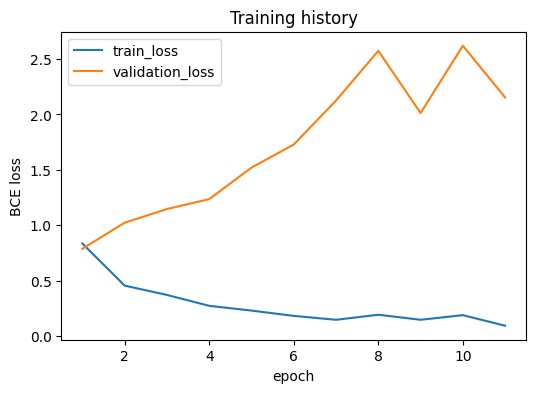

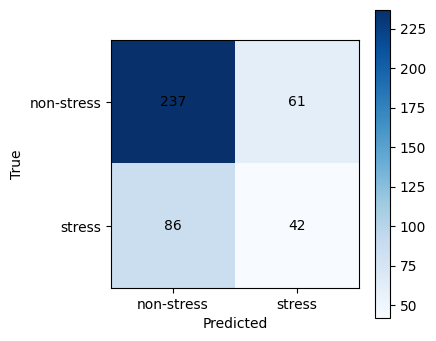

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
history.plot(x="epoch", y=["train_loss", "validation_loss"], ax=ax)
ax.set_title("Training history")
ax.set_ylabel("BCE loss")
plt.show()

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["non-stress", "stress"])
ax.set_yticks([0, 1], labels=["non-stress", "stress"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.show()


## 17. Plot ROC and precision-recall curves


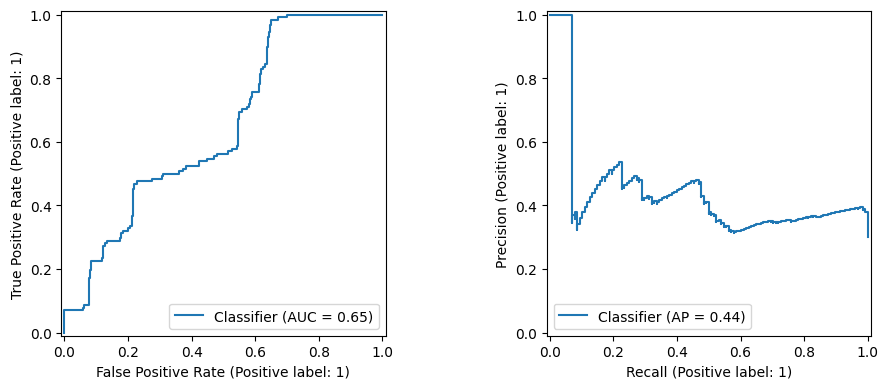

In [18]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(test_true, test_probabilities, ax=axes[0])
PrecisionRecallDisplay.from_predictions(test_true, test_probabilities, ax=axes[1])
plt.tight_layout()
plt.show()


## 18. Save model and results


In [19]:
artifact_dir = PROJECT_ROOT / "artifacts" / "models" / "cnn_gru"
test_predictions = prediction_table(metadata_test, test_true, test_probabilities, threshold)

save_model_artifacts(
    artifact_dir=artifact_dir,
    model=model,
    model_config={ "model": "CNNGRUClassifier", "input_channels": int(X_train.shape[2]), "conv_channels": 32, "hidden_size": 64, "dropout": 0.3,
        "parameter_count": count_parameters(model),
        "selected_imbalance_method": selected_method,
        "best_validation_epoch": selected_best_epoch,
        "random_seed": RANDOM_SEED, "uses_class_weighting": selected_method == "class_weight" },
    threshold=threshold,
    history=history,
    validation_metrics=validation_metrics,
    test_metrics=test_metrics,
    per_subject=subject_metrics,
    test_predictions=test_predictions,
    training_summary={**selected_training_summary, "selected_imbalance_method": selected_method, "inference_time_seconds": inference_time_seconds},
)
artifact_dir


WindowsPath('C:/Users/User/Documents/deep-learning/deep-learning/artifacts/models/cnn_gru')